# NYC Motor Vehicle Collisions
## Week 4 — Advanced Visualizations + Visual Integrity

**Project:** NYC Crashes EDA  
**Focus:** Polished, ethical, and intentional charts that support the emerging story

---

## 🔍 Ethics Reflection — Before Any Visual

Before revising or creating charts this week, I paused to ask the following questions:

| Question | Reflection |
|---|---|
| **Are there biases in data collection?** | Yes. Crashes are reported by the NYPD — unreported incidents are not captured. Minor fender-benders may go unreported. |
| **Are groups underrepresented?** | Missing `borough` data (~30% of records) means some neighborhoods may be undercounted. Pedestrians and cyclists may be underrepresented in contributing factors. |
| **Could charts mislead?** | Bar charts starting at non-zero, or comparing boroughs without normalizing by population, could exaggerate differences. |
| **Does data need context?** | Yes. Population per borough varies greatly — raw crash counts favor densely populated areas. |
| **Am I telling the full story?** | I will acknowledge limitations in every chart's annotation. |

> **Commitment:** Every visual this week will use full-range axes, proper labels, accessible colors, and a note on limitations where relevant.

## 📦 Setup — Libraries & Global Style

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global style ─────────────────────────────────────────────
# Using a colorblind-friendly palette (avoids red/green confusion)
CB_PALETTE = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#56B4E9', '#D55E00']

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.facecolor' : 'white',
})

print('Libraries loaded. Colorblind-friendly palette active.')

Libraries loaded. Colorblind-friendly palette active.


## 🔧 Data Loading & Cleaning (Reproducible from Scratch)

In [7]:
# Load
df = pd.read_csv('data/nyc_crashes.csv')

# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Rename for readability
df.rename(columns={
    'crash_date'                    : 'date',
    'crash_time'                    : 'time',
    'number_of_persons_injured'     : 'injured',
    'number_of_persons_killed'      : 'killed',
    'contributing_factor_vehicle_1' : 'main_cause',
    'vehicle_type_code1'            : 'vehicle_type',
    'collision_id'                  : 'id',
}, inplace=True)

# Fix types
df['date']    = pd.to_datetime(df['date'], errors='coerce')
df['injured'] = pd.to_numeric(df['injured'], errors='coerce').fillna(0).astype(int)
df['killed']  = pd.to_numeric(df['killed'],  errors='coerce').fillna(0).astype(int)

# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop low-value columns
cols_to_drop = [
    'location','cross_street_name','off_street_name',
    'contributing_factor_vehicle_3','contributing_factor_vehicle_4',
    'contributing_factor_vehicle_5',
    'vehicle_type_code_3','vehicle_type_code_4','vehicle_type_code_5',
]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Fill missing borough
df['borough'] = df['borough'].fillna('UNKNOWN')

# Clean main_cause
df['main_cause'] = df['main_cause'].replace('Unspecified', np.nan)

# Feature engineering
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['month_name']  = df['date'].dt.strftime('%b')
df['day_of_week'] = df['date'].dt.day_name()
df['hour']        = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour

def severity(row):
    if row['killed']  > 0: return 'Fatal'
    elif row['injured'] > 0: return 'Injury'
    else: return 'Property Only'

df['severity'] = df.apply(severity, axis=1)

def time_of_day(h):
    if pd.isna(h): return 'Unknown'
    h = int(h)
    if   6 <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else: return 'Night'

df['time_of_day'] = df['hour'].apply(time_of_day)

print(f'✓ Dataset ready: {len(df):,} rows | {df.shape[1]} columns')
print(f'  Date range: {df["date"].min().date()} → {df["date"].max().date()}')
df.head(3)

✓ Dataset ready: 2,262,089 rows | 27 columns
  Date range: 2012-07-01 → 2026-05-12


,date,time,borough,zip_code,latitude,longitude,on_street_name,injured,killed,number_of_pedestrians_injured,...,id,vehicle_type_code_1,vehicle_type_code_2,year,month,month_name,day_of_week,hour,severity,time_of_day
0,2021-09-11,2:39,UNKNOWN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,2,0,0,...,4455765,Sedan,Sedan,2021,9,Sep,Saturday,2,Injury,Night
1,2022-03-26,11:45,UNKNOWN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,1,0,0,...,4513547,Sedan,NaN,2022,3,Mar,Saturday,11,Injury,Morning
2,2023-11-01,1:29,BROOKLYN,11230.0,40.62179,-73.970024,OCEAN PARKWAY,1,0,0,...,4675373,Moped,Sedan,2023,11,Nov,Wednesday,1,Injury,Night


---
## 📊 Visual 1 — Distribution: Injuries per Crash

**Question:** How are injuries distributed across crashes that resulted in at least one injury?

**Chart type:** Histogram — best for showing the shape, spread, and skewness of a numeric variable.

**Design choices:**
- X-axis starts at 1 (not 0) since we filter for crashes *with* injuries — no truncation
- Median line added for reference without distorting the scale
- Single neutral color avoids false categorical impression
- Bin count kept moderate (25) to avoid over-smoothing or over-fragmenting

**Accuracy & integrity:**
- Chart title and subtitle clarify the filtered subset
- Annotation notes that extreme outliers exist but are rare
- No axis truncation — y-axis starts at 0

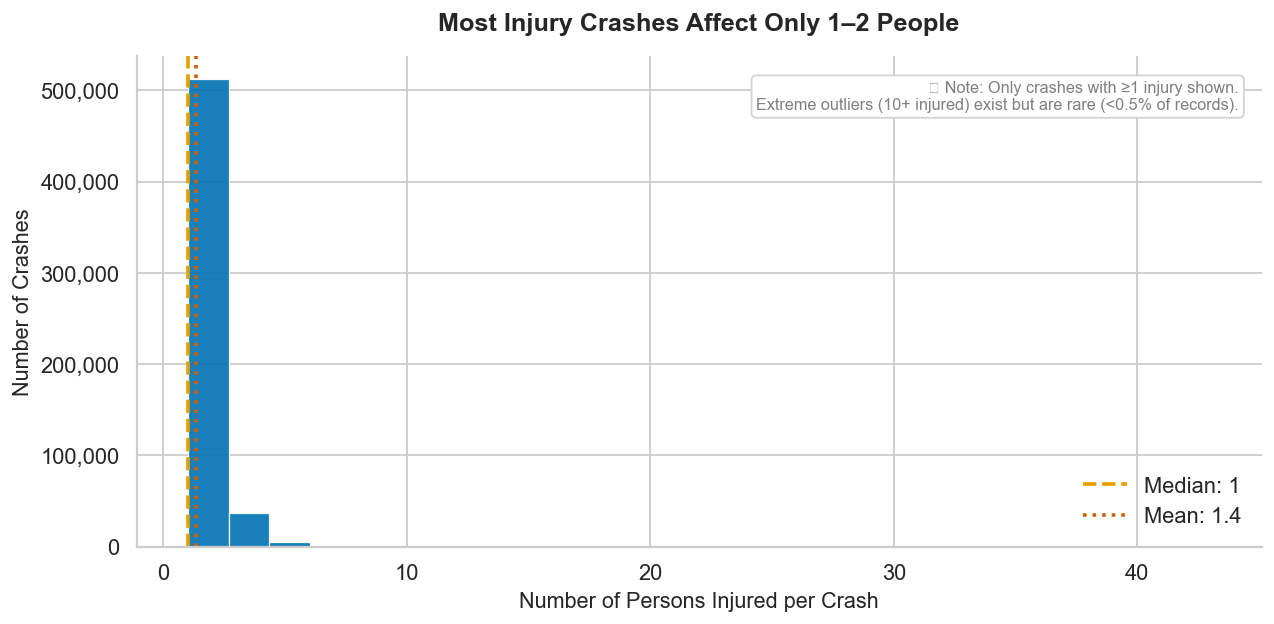

Crashes with injuries: 555,300 | Median: 1.0 | Mean: 1.35


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

injury_data = df[df['injured'] > 0]['injured']
median_val  = injury_data.median()
mean_val    = injury_data.mean()

ax.hist(injury_data, bins=25, color=CB_PALETTE[0], edgecolor='white', linewidth=0.7, alpha=0.9)

ax.axvline(median_val, color='#E69F00', linestyle='--', linewidth=2,
           label=f'Median: {median_val:.0f}')
ax.axvline(mean_val,   color='#D55E00', linestyle=':',  linewidth=2,
           label=f'Mean: {mean_val:.1f}')

ax.set_title('Most Injury Crashes Affect Only 1–2 People', pad=14)
ax.set_xlabel('Number of Persons Injured per Crash')
ax.set_ylabel('Number of Crashes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(frameon=False)

ax.annotate(
    '⚠ Note: Only crashes with ≥1 injury shown.\nExtreme outliers (10+ injured) exist but are rare (<0.5% of records).',
    xy=(0.98, 0.95), xycoords='axes fraction',
    ha='right', va='top', fontsize=9, color='gray',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray')
)

plt.tight_layout()
plt.savefig('plots/v1_injury_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Crashes with injuries: {len(injury_data):,} | Median: {median_val} | Mean: {mean_val:.2f}')

---
## 📊 Visual 2 — Comparison: Crashes by Borough

**Question:** Which boroughs record the most crashes — and what does that tell us, considering population differences?

**Chart type:** Horizontal bar chart — ideal for comparing ranked categories with readable labels.

**Design choices:**
- Sorted descending so the eye immediately reads the ranking
- UNKNOWN borough excluded from the main chart but called out in the note
- Single color family (sequential blue) avoids implying categorical meaning
- Data labels added directly on bars — no need to read the axis back and forth

**Accuracy & integrity:**
- ⚠ Population disclaimer is included: Brooklyn has more crashes partly because it has more people
- UNKNOWN records (~missing borough) are explicitly acknowledged
- Axis starts at 0 — no truncation

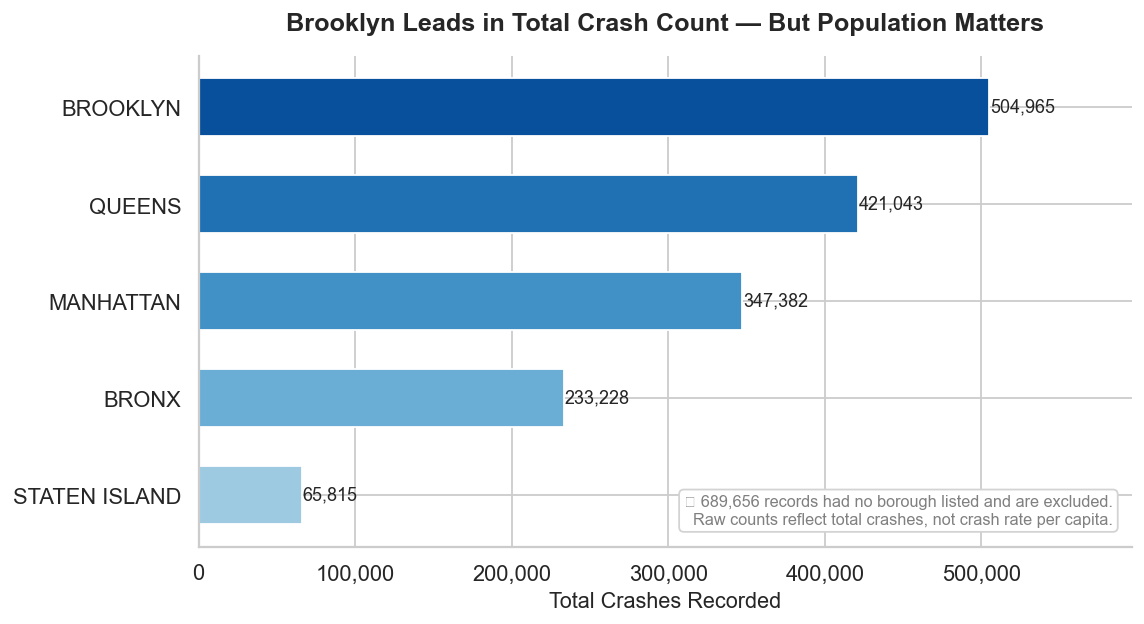

In [10]:
borough_counts = (
    df[df['borough'] != 'UNKNOWN']
    .groupby('borough')
    .size()
    .reset_index(name='crashes')
    .sort_values('crashes', ascending=True)   # ascending for horizontal barh
)

unknown_count = (df['borough'] == 'UNKNOWN').sum()

fig, ax = plt.subplots(figsize=(9, 5))

colors = sns.color_palette('Blues', len(borough_counts) + 2)[2:]
bars = ax.barh(borough_counts['borough'], borough_counts['crashes'],
               color=colors, edgecolor='white', height=0.6)

# Data labels
for bar, val in zip(bars, borough_counts['crashes']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left', fontsize=10)

ax.set_title('Brooklyn Leads in Total Crash Count — But Population Matters', pad=14)
ax.set_xlabel('Total Crashes Recorded')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, borough_counts['crashes'].max() * 1.18)

ax.annotate(
    f'⚠ {unknown_count:,} records had no borough listed and are excluded.\n'
    'Raw counts reflect total crashes, not crash rate per capita.',
    xy=(0.98, 0.04), xycoords='axes fraction',
    ha='right', va='bottom', fontsize=9, color='gray',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray')
)

plt.tight_layout()
plt.savefig('plots/v2_crashes_by_borough.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 📊 Visual 3 — Trend Over Time: Monthly Crashes by Year

**Question:** Has the number of crashes changed over the years? Are there seasonal patterns?

**Chart type:** Line chart — best for showing change over continuous time.

**Design choices:**
- Each year is a separate line with distinct color from a colorblind-friendly palette
- Markers added to make individual monthly points readable
- Grid lines kept light — they guide reading without competing with the data
- Legend placed outside the plot area to avoid overlapping lines

**Accuracy & integrity:**
- Y-axis starts at 0 to show true magnitude differences
- 2020 COVID dip is annotated — without context it could be misread as a data error
- Incomplete years (first/last) are displayed but noted in the annotation

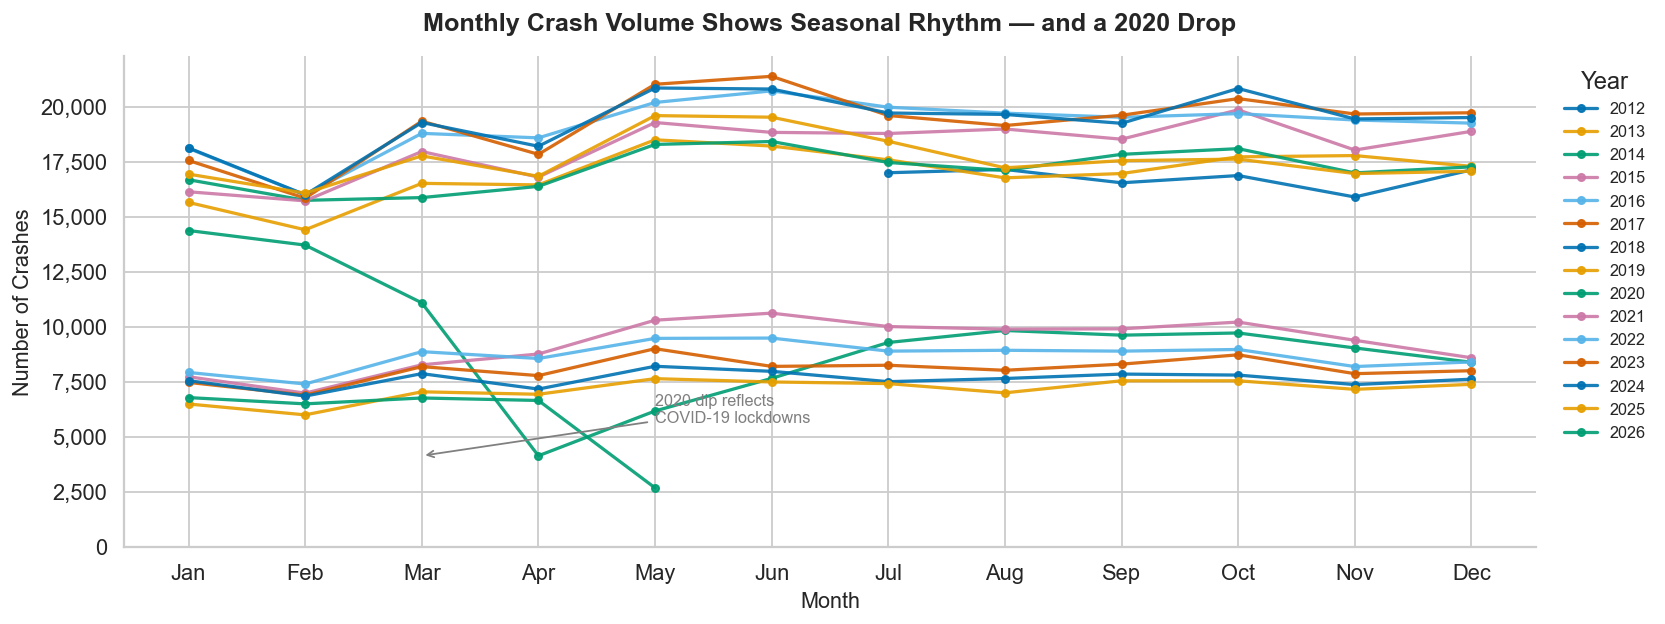

In [11]:
monthly = (
    df.groupby(['year', 'month'])
    .size()
    .reset_index(name='crashes')
)
monthly['date'] = pd.to_datetime(monthly[['year','month']].assign(day=1))

years     = sorted(monthly['year'].unique())
palette   = sns.color_palette(CB_PALETTE, len(years))

fig, ax = plt.subplots(figsize=(13, 5))

for yr, color in zip(years, palette):
    grp = monthly[monthly['year'] == yr]
    ax.plot(grp['month'], grp['crashes'],
            marker='o', markersize=4, linewidth=1.8,
            color=color, label=str(yr), alpha=0.9)

ax.set_title('Monthly Crash Volume Shows Seasonal Rhythm — and a 2020 Drop', pad=14)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Crashes')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, frameon=False)

ax.annotate(
    '2020 dip reflects\nCOVID-19 lockdowns',
    xy=(3, monthly[(monthly['year']==2020) & (monthly['month']==4)]['crashes'].values[0]),
    xytext=(5, monthly[(monthly['year']==2020) & (monthly['month']==4)]['crashes'].values[0] + 1500),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

plt.tight_layout()
plt.savefig('plots/v3_monthly_trend.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 📊 Visual 4 — Pattern: Crashes by Hour of Day

**Question:** At what time of day are crashes most concentrated?

**Chart type:** Bar chart with 24-hour x-axis — shows the cyclical daily pattern clearly without distorting time as continuous.

**Design choices:**
- Color encodes time-of-day zones (morning / afternoon / evening / night) using colorblind-safe hues
- Rush-hour windows are annotated directly on the chart
- Bars for each hour rather than smoothed lines — avoids implying interpolation between hours

**Accuracy & integrity:**
- Records with unknown hour (~missing time field) excluded and disclosed
- Y-axis starts at 0
- Color legend clearly labeled — colors are not decorative, they carry meaning

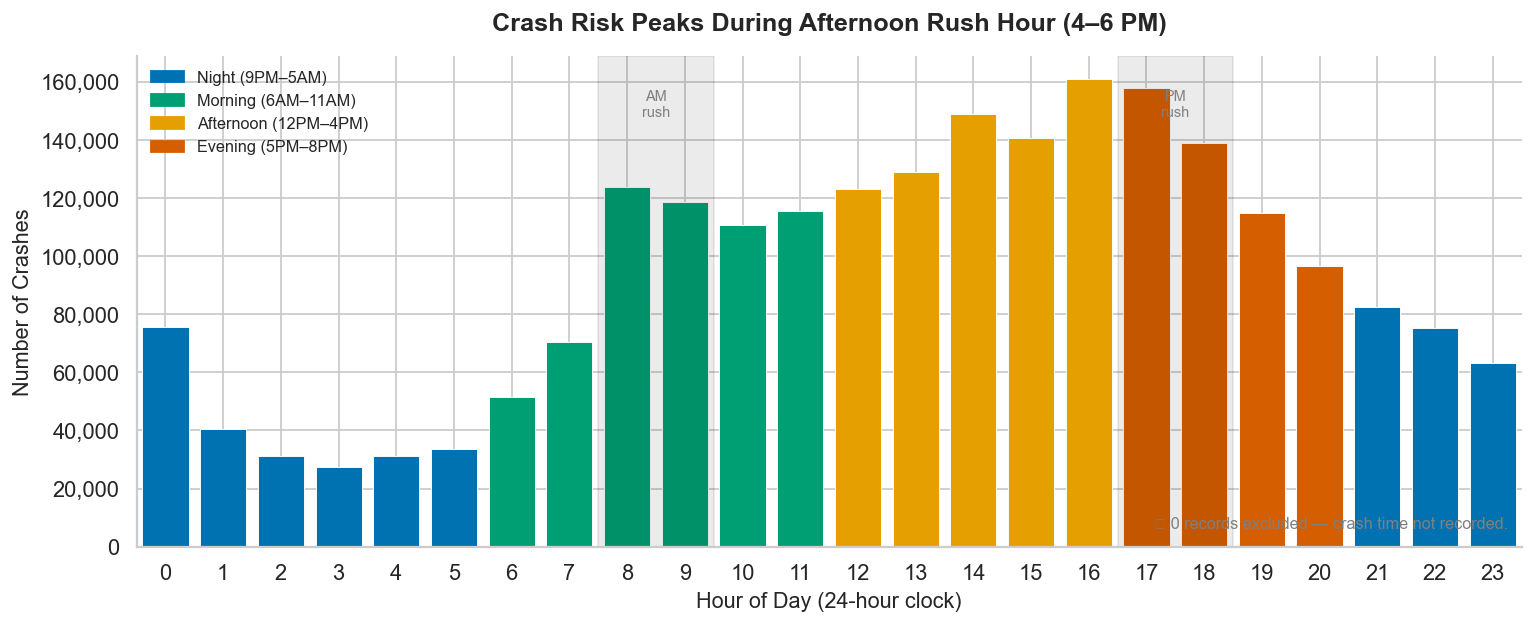

In [12]:
by_hour = df.dropna(subset=['hour']).groupby('hour').size().reset_index(name='crashes')
missing_hour = df['hour'].isna().sum()

def hour_color(h):
    if   6  <= h < 12: return CB_PALETTE[2]   # green  = morning
    elif 12 <= h < 17: return CB_PALETTE[1]   # orange = afternoon
    elif 17 <= h < 21: return CB_PALETTE[5]   # red    = evening
    else:               return CB_PALETTE[0]   # blue   = night

colors = [hour_color(h) for h in by_hour['hour']]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(by_hour['hour'], by_hour['crashes'], color=colors, edgecolor='white', linewidth=0.5)

ax.set_title('Crash Risk Peaks During Afternoon Rush Hour (4–6 PM)', pad=14)
ax.set_xlabel('Hour of Day (24-hour clock)')
ax.set_ylabel('Number of Crashes')
ax.set_xticks(range(0, 24))
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Annotate rush hours
ax.axvspan(7.5, 9.5, alpha=0.08, color='black', label='_nolegend_')
ax.axvspan(16.5, 18.5, alpha=0.08, color='black', label='_nolegend_')
ax.text(8.5,  by_hour['crashes'].max()*0.92, 'AM\nrush', ha='center', fontsize=8, color='gray')
ax.text(17.5, by_hour['crashes'].max()*0.92, 'PM\nrush', ha='center', fontsize=8, color='gray')

# Legend
legend_patches = [
    mpatches.Patch(color=CB_PALETTE[0], label='Night (9PM–5AM)'),
    mpatches.Patch(color=CB_PALETTE[2], label='Morning (6AM–11AM)'),
    mpatches.Patch(color=CB_PALETTE[1], label='Afternoon (12PM–4PM)'),
    mpatches.Patch(color=CB_PALETTE[5], label='Evening (5PM–8PM)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9, frameon=False)

ax.annotate(
    f'⚠ {missing_hour:,} records excluded — crash time not recorded.',
    xy=(0.99, 0.03), xycoords='axes fraction',
    ha='right', va='bottom', fontsize=9, color='gray'
)

plt.tight_layout()
plt.savefig('plots/v4_crashes_by_hour.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 📊 Visual 5 — Severity Breakdown by Borough (Stacked Bar)

**Question:** Does crash severity vary by borough — or is the proportion of fatal, injury, and property-only crashes similar everywhere?

**Chart type:** 100% stacked bar chart — shows proportional composition across categories without being distorted by raw count differences between boroughs.

**Design choices:**
- Percentage-normalized so boroughs with more crashes don't visually dominate
- Fatal crashes highlighted in a distinct warm color — they are rare but critical
- Order: Fatal → Injury → Property Only (most to least severe, top to bottom)
- Direct labels on segments above 5% to reduce need for legend lookup

**Accuracy & integrity:**
- Proportional view makes comparison fair across boroughs of different sizes
- Fatal % is very small — the chart does not exaggerate it
- UNKNOWN borough excluded to avoid misleading the borough comparison

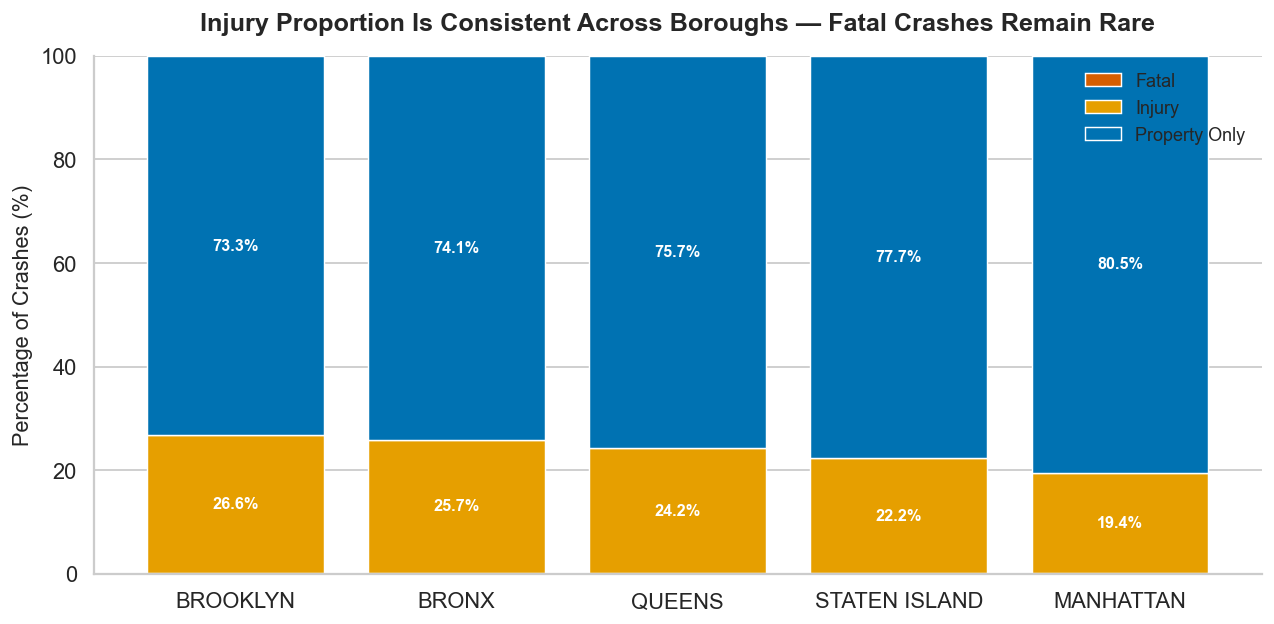

In [13]:
severity_order   = ['Fatal', 'Injury', 'Property Only']
severity_colors  = {'Fatal': '#D55E00', 'Injury': '#E69F00', 'Property Only': '#0072B2'}

pivot = (
    df[df['borough'] != 'UNKNOWN']
    .groupby(['borough', 'severity'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=severity_order)
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.sort_values('Injury', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(pivot_pct))
for sev in severity_order:
    vals = pivot_pct[sev].values
    bars = ax.bar(pivot_pct.index, vals, bottom=bottom,
                  color=severity_colors[sev], label=sev,
                  edgecolor='white', linewidth=0.8)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bottom[i] + val/2,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Injury Proportion Is Consistent Across Boroughs — Fatal Crashes Remain Rare', pad=14)
ax.set_ylabel('Percentage of Crashes (%)')
ax.set_xlabel('')
ax.set_ylim(0, 100)
ax.legend(loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('plots/v5_severity_by_borough.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 📊 Visual 6 — Top Contributing Causes (Cleaned)

**Question:** What are the most commonly cited causes of crashes, after removing vague or unspecified entries?

**Chart type:** Horizontal bar chart — ranked, readable labels, easy to compare magnitudes.

**Design choices:**
- 'Unspecified' was removed during cleaning — keeping it would make it #1 and hide real insight
- Bars sorted descending for immediate rank reading
- Percentage labels added so viewers understand relative scale

**Accuracy & integrity:**
- Annotation discloses that 'Unspecified' was excluded and how many records it represented
- Causes reflect only vehicle 1 — multi-vehicle incidents may have additional factors

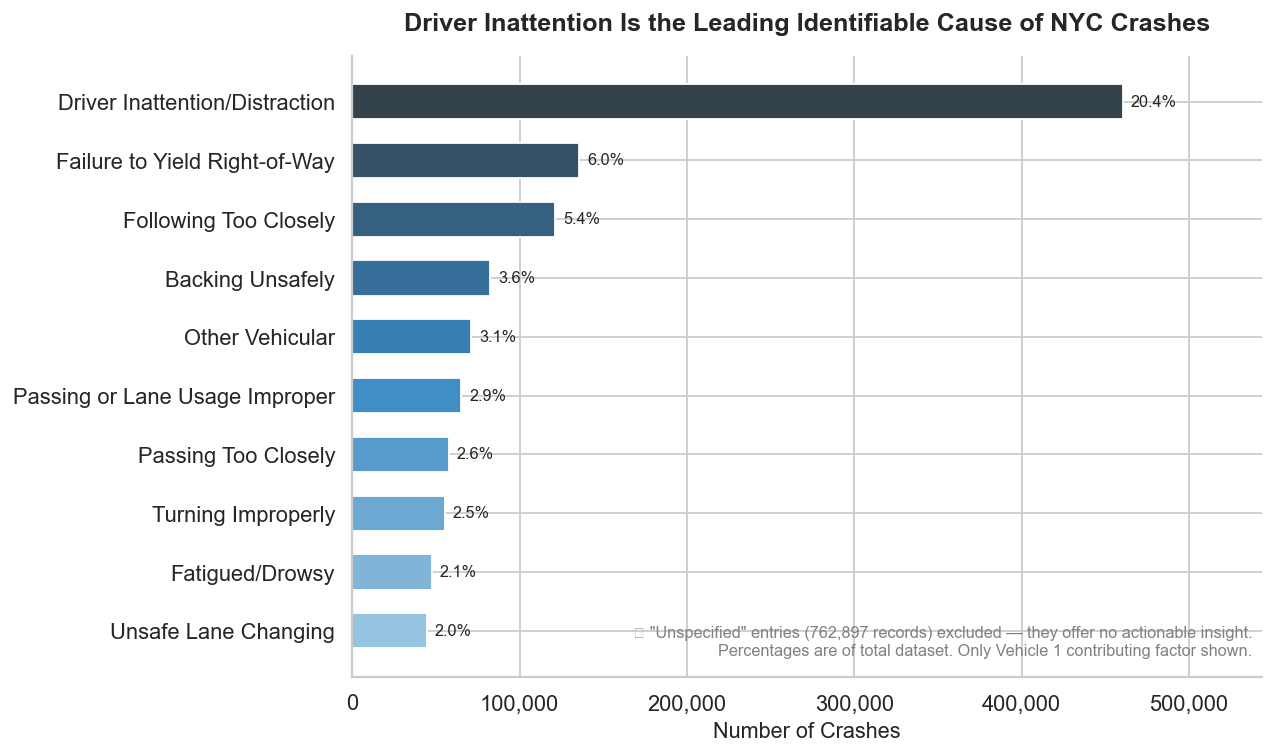

In [14]:
cause_counts = df['main_cause'].dropna().value_counts()
top_causes   = cause_counts.head(10).reset_index()
top_causes.columns = ['cause', 'count']
top_causes['pct'] = top_causes['count'] / len(df) * 100
top_causes = top_causes.sort_values('count', ascending=True)  # for barh

unspecified_n = (df['main_cause'].isna().sum() +
                 (df['main_cause'] == 'Unspecified').sum())

fig, ax = plt.subplots(figsize=(10, 6))

palette = sns.color_palette('Blues_d', len(top_causes))
bars = ax.barh(top_causes['cause'], top_causes['count'],
               color=palette, edgecolor='white', height=0.6)

for bar, pct in zip(bars, top_causes['pct']):
    ax.text(bar.get_width() + top_causes['count'].max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.set_title('Driver Inattention Is the Leading Identifiable Cause of NYC Crashes', pad=14)
ax.set_xlabel('Number of Crashes')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, top_causes['count'].max() * 1.18)

ax.annotate(
    f'⚠ "Unspecified" entries ({unspecified_n:,} records) excluded — they offer no actionable insight.\n'
    'Percentages are of total dataset. Only Vehicle 1 contributing factor shown.',
    xy=(0.99, 0.03), xycoords='axes fraction',
    ha='right', va='bottom', fontsize=9, color='gray'
)

plt.tight_layout()
plt.savefig('plots/v6_top_causes.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 🧹 Cleanup — Removing Exploratory-Only Code

The following items from Week 3's EDA have been **removed or replaced** in this notebook:

| Removed | Reason |
|---|---|
| Raw `value_counts()` print blocks | Replaced by polished charts |
| First histogram draft (no median, no annotation) | Replaced by Visual 1 |
| Bar chart with 'UNKNOWN' included | Replaced by Visual 2 with disclaimer |
| Bonus hour chart with `RdYlGn_r` (not colorblind safe) | Replaced by Visual 4 with labeled color zones |

> **TODO:** Add geospatial heat map if `latitude`/`longitude` columns have sufficient coverage.